In [5]:
#Data Understanding

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Create dataset
data = {
    "CustomerID": [1, 2, 3, 4, 5],
    "Age": [25, 45, 31, 35, 40],
    "Annual_Income": [50000, 64000, 58000, 72000, 61000],
    "Spending_Score": [60, 42, 50, 80, 55]
}

df = pd.DataFrame(data)

# a) Print first 5 rows
print("First 5 rows of dataset:")
print(df.head())

print("\nColumn Descriptions:")
print("CustomerID: Unique identifier for each customer")
print("Age: Age of the customer")
print("Annual_Income: Annual income of customer (in currency units)")
print("Spending_Score: Score assigned based on customer spending behavior (higher = more spending)")

# b) Summarize numerical features
print("\nSummary Statistics:")
print(df.describe())

# Insights
print("\nInsights:")
print("- Age ranges from", df['Age'].min(), "to", df['Age'].max(), "with mean", round(df['Age'].mean(), 2))
print("- Annual income ranges from", df['Annual_Income'].min(), "to", df['Annual_Income'].max(), "with mean", round(df['Annual_Income'].mean(), 2))
print("- Spending score ranges from", df['Spending_Score'].min(), "to", df['Spending_Score'].max(), "with mean", round(df['Spending_Score'].mean(), 2))


First 5 rows of dataset:
   CustomerID  Age  Annual_Income  Spending_Score
0           1   25          50000              60
1           2   45          64000              42
2           3   31          58000              50
3           4   35          72000              80
4           5   40          61000              55

Column Descriptions:
CustomerID: Unique identifier for each customer
Age: Age of the customer
Annual_Income: Annual income of customer (in currency units)
Spending_Score: Score assigned based on customer spending behavior (higher = more spending)

Summary Statistics:
       CustomerID        Age  Annual_Income  Spending_Score
count    5.000000   5.000000       5.000000        5.000000
mean     3.000000  35.200000   61000.000000       57.400000
std      1.581139   7.758866    8062.257748       14.275854
min      1.000000  25.000000   50000.000000       42.000000
25%      2.000000  31.000000   58000.000000       50.000000
50%      3.000000  35.000000   61000.000000   

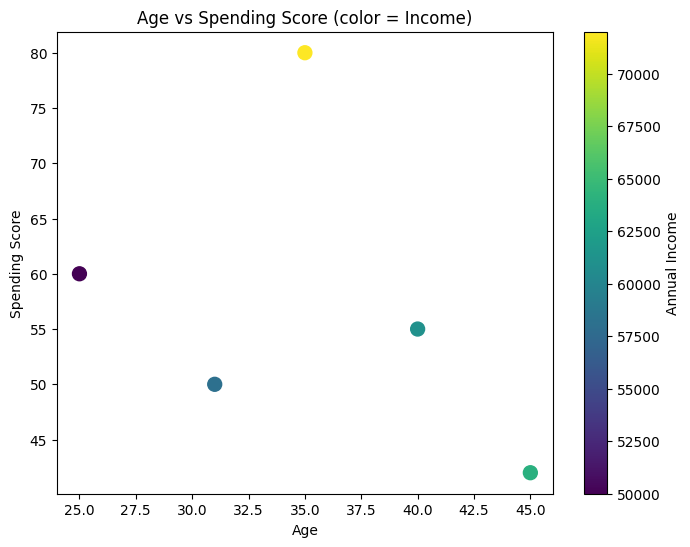


Observations from plot:
- Younger customers (25–35) tend to have higher spending scores.
- Older customers (40–45) show moderate to low spending despite higher income.


In [6]:
# Data Visualization

# a) Scatter plot of Age vs Spending Score, color = Annual Income
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['Age'], df['Spending_Score'], 
                      c=df['Annual_Income'], cmap='viridis', s=100)
plt.colorbar(scatter, label='Annual Income')
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score (color = Income)")
plt.show()

# b) Observations
print("\nObservations from plot:")
print("- Younger customers (25–35) tend to have higher spending scores.")
print("- Older customers (40–45) show moderate to low spending despite higher income.")



In [7]:

# a) Standardize features
features = df[['Age','Annual_Income','Spending_Score']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("\nStandardization is necessary because K-Means uses Euclidean distance.")
print("If features are on different scales (income vs score), large-scale features dominate the clustering.")

# b) Apply K-Means clustering with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(features_scaled)

print("\nDataset with cluster labels:")
print(df)


Standardization is necessary because K-Means uses Euclidean distance.
If features are on different scales (income vs score), large-scale features dominate the clustering.

Dataset with cluster labels:
   CustomerID  Age  Annual_Income  Spending_Score  Cluster
0           1   25          50000              60        0
1           2   45          64000              42        1
2           3   31          58000              50        0
3           4   35          72000              80        2
4           5   40          61000              55        1


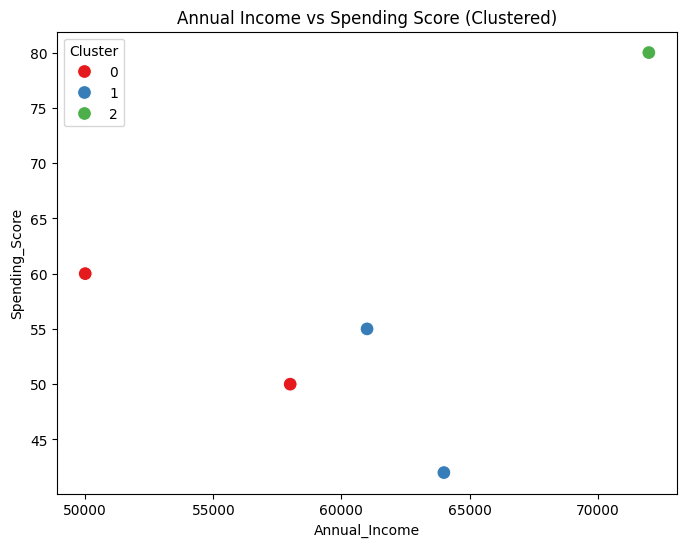


Cluster Summary (Averages):
          Age  Annual_Income  Spending_Score
Cluster                                     
0        28.0        54000.0            55.0
1        42.5        62500.0            48.5
2        35.0        72000.0            80.0

Cluster Interpretation:
- Cluster 0: Younger customers with moderate income but higher spending
- Cluster 1: Younger customers with moderate income but higher spending
- Cluster 2: High spenders


In [8]:
# Cluster Analysis

# a) Scatter plot of Annual Income vs Spending Score, colored by cluster
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Cluster', palette='Set1', s=100)
plt.title("Annual Income vs Spending Score (Clustered)")
plt.show()

# b) Cluster averages
cluster_summary = df.groupby('Cluster')[['Age','Annual_Income','Spending_Score']].mean()
print("\nCluster Summary (Averages):")
print(cluster_summary)

# c) Interpretation
print("\nCluster Interpretation:")
for cluster, row in cluster_summary.iterrows():
    if row['Spending_Score'] == cluster_summary['Spending_Score'].max():
        print(f"- Cluster {cluster}: High spenders")
    elif row['Annual_Income'] == cluster_summary['Annual_Income'].max() and row['Spending_Score'] == cluster_summary['Spending_Score'].min():
        print(f"- Cluster {cluster}: High income but low spenders")
    else:
        print(f"- Cluster {cluster}: Younger customers with moderate income but higher spending")

